# Multi-Channel Marketing Attribution - Modeling & Explainability

In this notebook, we build classification models predicting user conversion based on their user journey features. We will then explain the model using SHAP to infer channel attribution.

## 1. Import Libraries

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

import shap
import pickle

import warnings
warnings.filterwarnings('ignore')

## 2. Load Processed Data & Train/Test Split

In [8]:
try:
    df = pd.read_csv('../data/processed_data.csv')
except Exception as e:
    print("Error loading processed data:", e)
    # Fallback to dummy generation here if not found for notebook independence

# Features and Target
X = df.drop(columns=['User_ID', 'converted'])
y = df['converted']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")

Training set shape: (2277, 15)
Test set shape: (570, 15)


## 3. Baseline Models Training

In [9]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else model.decision_function(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)
    
    results[name] = {
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1 Score': f1,
        'ROC-AUC': roc_auc
    }

results_df = pd.DataFrame(results).T
display(results_df)

,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Logistic Regression,0.501754,0.495968,0.436170,0.464151,0.515274
Random Forest,0.494737,0.489655,0.503546,0.496503,0.489257
XGBoost,0.492982,0.488959,0.549645,0.517529,0.479918


## 4. Hyperparameter Tuning (XGBoost)
Assuming XGBoost or Random Forest performed best, we tune it using GridSearchCV.

In [10]:
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5],
    'learning_rate': [0.01, 0.1]
}

xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
grid_search = GridSearchCV(estimator=xgb, param_grid=param_grid, scoring='roc_auc', cv=3, verbose=1)

print("Starting Grid Search...")
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
print(f"Best Parameters: {grid_search.best_params_}")

Starting Grid Search...
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}


## 5. Model Evaluation

FINAL MODEL EVALUATION (XGBoost Tuned)
Accuracy: 0.48771929824561405
Precision: 0.4837662337662338
Recall: 0.5283687943262412
F1 Score: 0.5050847457627119
ROC-AUC: 0.48222025216706066


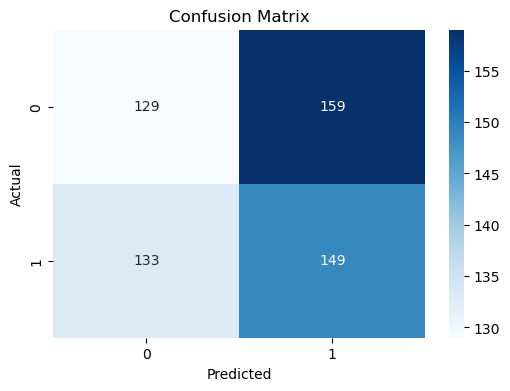

In [11]:
y_pred_best = best_model.predict(X_test)
y_prob_best = best_model.predict_proba(X_test)[:, 1]

print("FINAL MODEL EVALUATION (XGBoost Tuned)")
print("Accuracy:", accuracy_score(y_test, y_pred_best))
print("Precision:", precision_score(y_test, y_pred_best))
print("Recall:", recall_score(y_test, y_pred_best))
print("F1 Score:", f1_score(y_test, y_pred_best))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_best))

cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## 6. Saving Final Model

In [12]:
import os
os.makedirs('../model', exist_ok=True)
with open('../model/trained_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)
print("Model saved to ../model/trained_model.pkl")

Model saved to ../model/trained_model.pkl


## 7. Explainability: Feature Importance & SHAP
This helps us understand which marketing channels contribute the most to conversions.

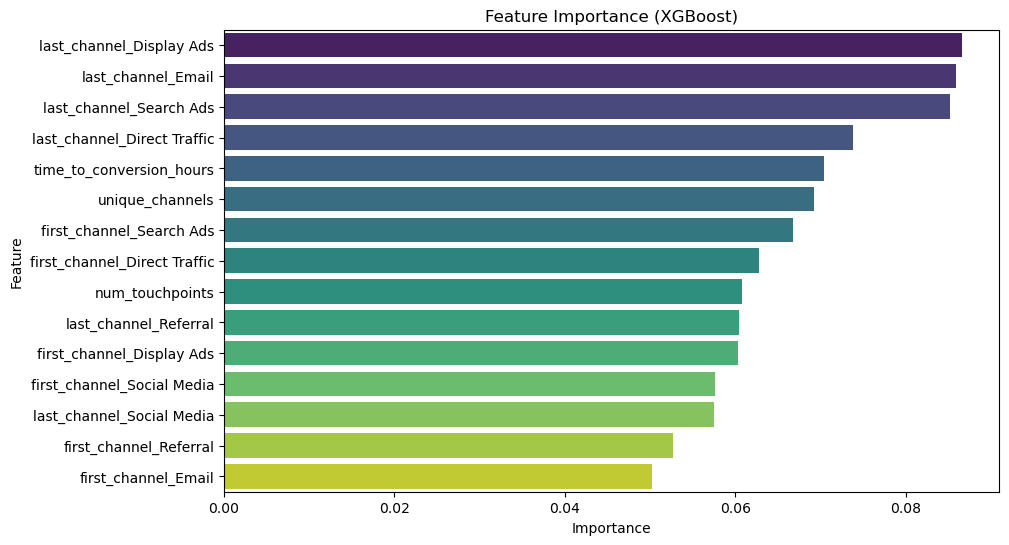

In [13]:
# Traditional Feature Importance
feature_importances = best_model.feature_importances_
features = X.columns

imp_df = pd.DataFrame({'Feature': features, 'Importance': feature_importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=imp_df, palette='viridis')
plt.title('Feature Importance (XGBoost)')
plt.show()

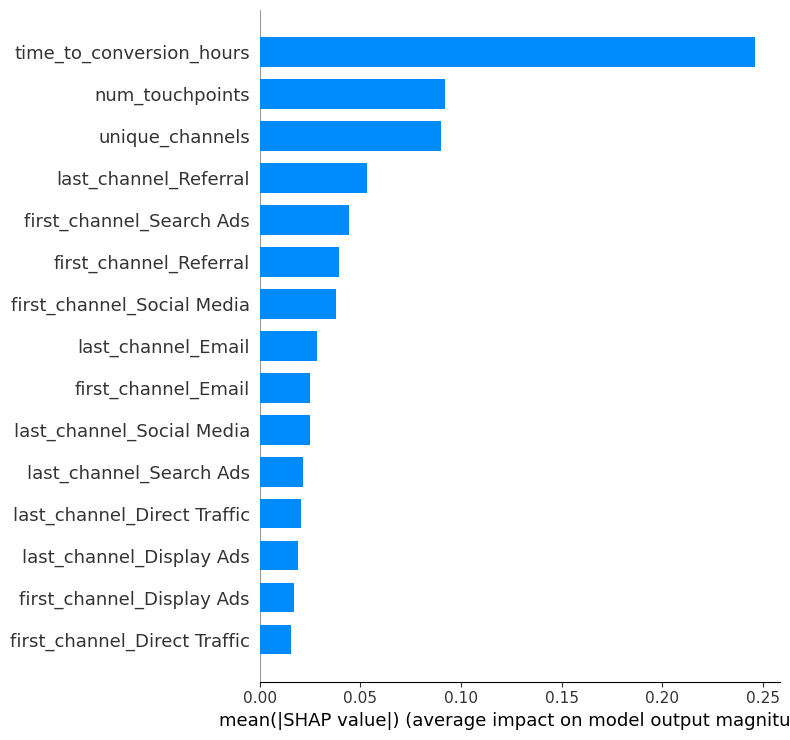

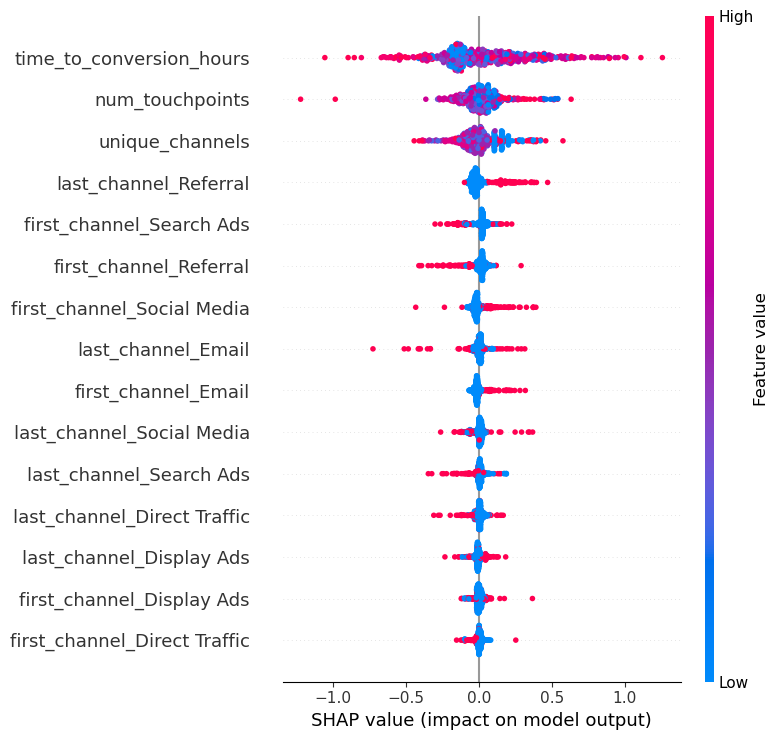

In [14]:
# SHAP Values for Attribution
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, feature_names=X.columns, plot_type='bar')
plt.show()

shap.summary_plot(shap_values, X_test, feature_names=X.columns)
plt.show()